# 22 — Gateway Decision Analysis: LSTM Surrogate vs Ground Truth

For each **decision point** (gateway) in the process, trains two decision trees
on identical prefixes:

1. **LSTM Surrogate** — target = model's predicted next activity
2. **Ground Truth** — target = actual next activity from the event log

Compares rules, feature importances, and agreement to reveal whether the LSTM
has learned the same decision logic that exists in the data.

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))

src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [2]:
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from src.interpretability.surrogate.c45_tree import C45Classifier

# --- Load dataset ---
data_path = _current / 'encoded_data' / 'test_philipp' / 'helpdesk_all_5_test.pkl'
dataset = torch.load(data_path, weights_only=False)

sample = dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]
print(f'Dataset: {len(dataset)} sequences, {n_cat} cat, {n_num} num, seq_len={seq_len}')

# --- Load model ---
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

model_path = (_current / 'src' / 'notebooks' / 'training_variational_dropout'
              / 'Helpdesk' / 'Helpdesk_full_grad_norm_new_4layer.pkl')
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(model_path), dropout=0.0)
model.eval()

# --- TensorDecoder + activity vocab ---
from src.interpretability.utils.tensor_decoder import TensorDecoder

decoder = TensorDecoder(dataset)

ACTIVITY_FEATURE = 'Activity'
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

# --- Predictor ---
from src.interpretability.perturbation_methods.revised_plus.revised_plus import RevisedPlusModelPredictor

predictor = RevisedPlusModelPredictor(model, suffix_step=0, activity_feature=ACTIVITY_FEATURE)

# --- Feature indices ---
ACT_IDX = 0    # Activity
RES_IDX = 1    # Resource
VAR_IDX = 2    # Variant index (case-level)

elapsed_num_idx = decoder.num_features.index('case_elapsed_time')
event_num_idx = decoder.num_features.index('event_elapsed_time')

print(f'Activity vocabulary ({len(activity_names)}), EOS={eos_idx}')
print(f'Cat features: {decoder.cat_features}')
print(f'Num features: {decoder.num_features}')

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

Dataset: 6077 sequences, 12 cat, 4 num, seq_len=18
Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('VariantIndex', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:163: DeprecationWarning: module 'sre_parse' is deprecated
  import sre_parse
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:164: DeprecationWarning: module 'sre_constants' is deprecated
  import sre_constants


Activity vocabulary (16), EOS=5
Cat features: ['Activity', 'Resource', 'Variant index', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup']
Num features: ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']


## Build DFG and identify qualifying gateways

A gateway is an activity with more than one observed successor. We filter to
gateways with at least `MIN_CASES` prefixes and at least two branches with
`MIN_BRANCH` cases each, so the decision trees have enough data.

In [3]:
MIN_CASES = 50       # minimum prefixes at this gateway
MIN_BRANCH = 10      # minimum cases per branch (need at least 2 branches above this)
MIN_SAMPLES_LEAF = 20

ACTIVITY_WINDOW = 40    # number of recent activities to include as positional features

# --- Collect unique cases (longest trace per case_id) ---
cases = {}
for i in range(len(dataset)):
    cat_t, num_t, case_id = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if case_id not in cases or trace_len > cases[case_id][1]:
        cases[case_id] = (i, trace_len)

print(f'{len(cases)} unique cases')

# --- Build DFG ---
dfg = {}
successors_map = {}

for case_id, (ds_idx, trace_len) in cases.items():
    cat_full = dataset[ds_idx][0]
    src_start = seq_len - trace_len
    acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

    # Strip trailing EOS
    useful_len = trace_len
    for j in range(trace_len - 1, -1, -1):
        if acts[j].item() == eos_idx:
            useful_len = j
        else:
            break

    act_names = [activity_names[acts[j].item()] for j in range(useful_len)]
    for k in range(len(act_names) - 1):
        edge = (act_names[k], act_names[k + 1])
        dfg[edge] = dfg.get(edge, 0) + 1

for (src, tgt), count in dfg.items():
    successors_map.setdefault(src, {})[tgt] = count

decision_points = {
    act: succs for act, succs in successors_map.items()
    if len(succs) > 1
}

print(f'\nDecision points ({len(decision_points)}):')
for act, succs in sorted(decision_points.items(), key=lambda x: -sum(x[1].values())):
    total = sum(succs.values())
    branches = ', '.join(f'{s} ({c}, {c/total*100:.0f}%)' for s, c in
                         sorted(succs.items(), key=lambda x: -x[1]))
    print(f'  {act} ({total} cases): {branches}')

916 unique cases

Decision points (9):
  Take in charge ticket (996 cases): Resolve ticket (717, 72%), Wait (243, 24%), Take in charge ticket (16, 2%), Require upgrade (12, 1%), Create SW anomaly (7, 1%), Schedule intervention (1, 0%)
  Assign seriousness (995 cases): Take in charge ticket (837, 84%), Assign seriousness (96, 10%), Resolve ticket (50, 5%), Wait (11, 1%), Require upgrade (1, 0%)
  Resolve ticket (987 cases): Closed (910, 92%), Resolve ticket (50, 5%), Take in charge ticket (26, 3%), RESOLVED (1, 0%)
  Wait (279 cases): Resolve ticket (153, 55%), Take in charge ticket (99, 35%), Wait (24, 9%), Require upgrade (1, 0%), Create SW anomaly (1, 0%), Assign seriousness (1, 0%)
  Insert ticket (28 cases): Assign seriousness (26, 93%), Wait (2, 7%)
  Require upgrade (20 cases): Resolve ticket (9, 45%), Require upgrade (4, 20%), Wait (3, 15%), Create SW anomaly (3, 15%), Take in charge ticket (1, 5%)
  Create SW anomaly (12 cases): Resolve ticket (8, 67%), Require upgrade (2, 17%)

## Collect per-gateway prefixes

For each qualifying gateway, find every prefix that ends at that activity (where
a real next activity exists). Extract both the actual next activity and the
LSTM's prediction, plus engineered features for the surrogate trees.

In [4]:
def extract_features(cat_tuple, num_tuple, decoder):
    """Extract engineered aggregate features from a single prefix."""
    act_tensor = cat_tuple[ACT_IDX]
    mask = act_tensor != 0
    prefix_len = int(mask.sum().item())
    if prefix_len == 0:
        return None

    nonzero = mask.nonzero(as_tuple=True)[0]
    start = nonzero[0].item()
    end = start + prefix_len

    acts = act_tensor[start:end]

    # Trailing repetitions of last activity
    last_act = acts[-1].item()
    repeated = 1
    for k in range(len(acts) - 2, -1, -1):
        if acts[k].item() == last_act:
            repeated += 1
        else:
            break

    # Time features (inverse-transformed)
    total_elapsed = decoder.decode_numerical_value(
        'case_elapsed_time', num_tuple[elapsed_num_idx][end - 1].item())
    last_event_dur = decoder.decode_numerical_value(
        'event_elapsed_time', num_tuple[event_num_idx][end - 1].item())
    event_durs = [decoder.decode_numerical_value(
        'event_elapsed_time', num_tuple[event_num_idx][j].item())
        for j in range(start, end)]
    mean_event_dur = float(np.mean(event_durs))

    # Resource features
    res_tensor = cat_tuple[RES_IDX]
    resources = res_tensor[start:end].tolist()
    n_unique_res = len(set(resources))

    feats = {
        'prefix_length': prefix_len,
        'first_activity': decoder.decode_categorical_value(ACT_IDX, acts[0].item()),
        'n_unique_activities': len(set(acts.tolist())),
        'last_activity_repeated': repeated,
        'total_elapsed_time': total_elapsed,
        'last_event_duration': last_event_dur,
        'mean_event_duration': mean_event_dur,
        'last_resource': decoder.decode_categorical_value(RES_IDX, res_tensor[end - 1].item()),
        'n_unique_resources': n_unique_res,
        'resource_changed': int(n_unique_res > 1),
    }

    # Raw last-position categorical values (skip Activity and Resource — already captured above)
    _skip_cat = {ACT_IDX, RES_IDX}
    for ci, feat_name in enumerate(decoder.cat_features):
        if ci in _skip_cat:
            continue
        val = cat_tuple[ci][end - 1].item()
        feats[f'last_{feat_name}'] = str(decoder.decode_categorical_value(ci, val))

    # Raw last-position numerical values (skip elapsed times — already captured above)
    _skip_num = {'case_elapsed_time', 'event_elapsed_time'}
    for ni, feat_name in enumerate(decoder.num_features):
        if feat_name in _skip_num:
            continue
        feats[f'last_{feat_name}'] = decoder.decode_numerical_value(
            feat_name, num_tuple[ni][end - 1].item())


    # Positional activity features: last WINDOW_SIZE activities in the prefix
    for w in range(1, ACTIVITY_WINDOW + 1):
        pos = len(acts) - w
        if pos >= 0:
            feats[f'act_pos_{-w}'] = decoder.decode_categorical_value(ACT_IDX, acts[pos].item())
        else:
            feats[f'act_pos_{-w}'] = '<pad>'

    return feats


# --- Collect gateway data ---
gateway_data = {}  # gateway_name -> {X, y_lstm, y_actual, cat_list, num_list}

for gateway_act, succs in decision_points.items():
    # Check if gateway qualifies
    qualifying_branches = [s for s, c in succs.items() if c >= MIN_BRANCH]
    if len(qualifying_branches) < 2 or sum(succs.values()) < MIN_CASES:
        continue

    feature_rows = []
    actual_labels = []
    cat_list = []
    num_list = []

    for case_id, (ds_idx, trace_len) in cases.items():
        cat_full, num_full, _ = dataset[ds_idx]
        src_start = seq_len - trace_len
        acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

        # Strip trailing EOS
        useful_len = trace_len
        for j in range(trace_len - 1, -1, -1):
            if acts[j].item() == eos_idx:
                useful_len = j
            else:
                break

        # Find all positions where activity == gateway and next activity exists
        for k in range(useful_len - 1):
            act_idx_val = acts[k].item()
            if activity_names[act_idx_val] != gateway_act:
                continue

            next_act_name = activity_names[acts[k + 1].item()]
            prefix_len = k + 1
            pad_len = seq_len - prefix_len

            # Build padded prefix tensors
            cat_prefix = []
            for c in cat_full:
                t = torch.zeros_like(c)
                t[pad_len:] = c[src_start:src_start + prefix_len]
                cat_prefix.append(t)
            num_prefix = []
            for n in num_full:
                t = torch.zeros_like(n)
                t[pad_len:] = n[src_start:src_start + prefix_len]
                num_prefix.append(t)

            feats = extract_features(tuple(cat_prefix), tuple(num_prefix), decoder)
            if feats is not None:
                feature_rows.append(feats)
                actual_labels.append(next_act_name)
                cat_list.append(cat_prefix)
                num_list.append(num_prefix)

    if len(feature_rows) < MIN_CASES:
        continue

    X = pd.DataFrame(feature_rows)
    y_actual = np.array(actual_labels)

    # Batch-predict LSTM labels
    N = len(X)
    cat_batch = [
        torch.stack([cat_list[i][ci] for i in range(N)])
        for ci in range(n_cat)
    ]
    num_stacked = torch.stack([
        torch.stack(num_list[i], dim=-1) for i in range(N)
    ])
    preds, probs = predictor.predict_batch(cat_batch, num_stacked, batch_size=128)
    y_lstm = np.array([activity_names[p] for p in preds])

    gateway_data[gateway_act] = {
        'X': X, 'y_lstm': y_lstm, 'y_actual': y_actual,
        'successors': succs, 'probs': probs,
    }

    # Report
    n_branches_actual = len(set(y_actual))
    n_branches_lstm = len(set(y_lstm))
    lstm_acc = (y_lstm == y_actual).mean()
    print(f'\n{gateway_act}: {N} prefixes, '
          f'{n_branches_actual} actual branches, {n_branches_lstm} LSTM branches, '
          f'LSTM accuracy={lstm_acc:.3f}')
    print(f'  Actual distribution: '
          + ', '.join(f'{a} ({c})' for a, c in
                      zip(*np.unique(y_actual, return_counts=True))))
    print(f'  LSTM   distribution: '
          + ', '.join(f'{a} ({c})' for a, c in
                      zip(*np.unique(y_lstm, return_counts=True))))

print(f'\n{len(gateway_data)} qualifying gateways: {list(gateway_data.keys())}')


Assign seriousness: 995 prefixes, 5 actual branches, 2 LSTM branches, LSTM accuracy=0.509
  Actual distribution: Assign seriousness (96), Require upgrade (1), Resolve ticket (50), Take in charge ticket (837), Wait (11)
  LSTM   distribution: Resolve ticket (400), Take in charge ticket (595)



Take in charge ticket: 996 prefixes, 6 actual branches, 3 LSTM branches, LSTM accuracy=0.674
  Actual distribution: Create SW anomaly (7), Require upgrade (12), Resolve ticket (717), Schedule intervention (1), Take in charge ticket (16), Wait (243)
  LSTM   distribution: Closed (19), Resolve ticket (833), Take in charge ticket (144)



Resolve ticket: 987 prefixes, 4 actual branches, 3 LSTM branches, LSTM accuracy=0.937
  Actual distribution: Closed (910), RESOLVED (1), Resolve ticket (50), Take in charge ticket (26)
  LSTM   distribution: Closed (948), Resolve ticket (38), Take in charge ticket (1)



Wait: 279 prefixes, 6 actual branches, 3 LSTM branches, LSTM accuracy=0.631
  Actual distribution: Assign seriousness (1), Create SW anomaly (1), Require upgrade (1), Resolve ticket (153), Take in charge ticket (99), Wait (24)
  LSTM   distribution: Closed (16), Resolve ticket (198), Take in charge ticket (65)

4 qualifying gateways: ['Assign seriousness', 'Take in charge ticket', 'Resolve ticket', 'Wait']


## Train surrogate and ground truth trees per gateway

For each gateway, the same stratified 60/20/20 train/validation/test
split is used for both trees so they are fit on identical training data,
selected on identical validation data, and evaluated on identical
held-out test data. Depth is swept on the validation set and the
shallowest tree within 2% of the best validation score is selected.
Final fidelity, accuracy, and agreement metrics are reported on the
held-out test set.

In [5]:
def select_best_depth(X_train, y_train, X_val, y_val, cat_features,
                      depths=(3, 4, 5, 6, 8, None)):
    """Sweep depths on validation set; prefer shallowest within 2% of best."""
    results = []
    for depth in depths:
        clf = C45Classifier(
            max_depth=depth, min_samples_leaf=MIN_SAMPLES_LEAF,
            class_weight='balanced', random_state=42)
        clf.fit(X_train, y_train, categorical_features=cat_features)
        train_sc = clf.score(X_train, y_train)
        val_sc = clf.score(X_val, y_val)
        results.append({'depth': depth, 'train': train_sc, 'val': val_sc, 'clf': clf})

    best_idx = 0
    best_val = results[0]['val']
    for i in range(1, len(results)):
        if results[i]['val'] > best_val + 0.02:
            best_idx = i
            best_val = results[i]['val']
    return results[best_idx]['clf'], results


# --- Train trees for each gateway ---
gateway_results = {}

for gateway_act, gd in gateway_data.items():
    X = gd['X']
    y_lstm = gd['y_lstm']
    y_actual = gd['y_actual']

    # Identify categorical columns (object dtype)
    cat_cols = [c for c in X.columns if X[c].dtype == 'object']

    # --- Three-way split: 60% train / 20% validation / 20% test ---
    # First split: 80% trainval / 20% test (held out for final metrics)
    try:
        X_trainval, X_test, y_lstm_tv, y_lstm_test, y_actual_tv, y_actual_test = \
            train_test_split(X, y_lstm, y_actual, test_size=0.2,
                             random_state=42, stratify=y_actual)
    except ValueError:
        X_trainval, X_test, y_lstm_tv, y_lstm_test, y_actual_tv, y_actual_test = \
            train_test_split(X, y_lstm, y_actual, test_size=0.2, random_state=42)

    # Second split: 75% of trainval = 60% total for training, 25% of trainval = 20% total for validation
    try:
        X_train, X_val, y_lstm_train, y_lstm_val, y_actual_train, y_actual_val = \
            train_test_split(X_trainval, y_lstm_tv, y_actual_tv, test_size=0.25,
                             random_state=42, stratify=y_actual_tv)
    except ValueError:
        X_train, X_val, y_lstm_train, y_lstm_val, y_actual_train, y_actual_val = \
            train_test_split(X_trainval, y_lstm_tv, y_actual_tv, test_size=0.25, random_state=42)

    feature_names = list(X.columns)

    # Train C4.5 trees on train set, select depth on validation set
    clf_lstm, lstm_sweep = select_best_depth(
        X_train, y_lstm_train, X_val, y_lstm_val, cat_cols)
    clf_gt, gt_sweep = select_best_depth(
        X_train, y_actual_train, X_val, y_actual_val, cat_cols)

    # --- Final metrics on held-out TEST set ---
    surrogate_fidelity = clf_lstm.score(X_test, y_lstm_test)
    gt_accuracy = clf_gt.score(X_test, y_actual_test)
    lstm_accuracy = (y_lstm_test == y_actual_test).mean()
    agreement = (clf_lstm.predict(X_test) == clf_gt.predict(X_test)).mean()

    gateway_results[gateway_act] = {
        'clf_lstm': clf_lstm, 'clf_gt': clf_gt,
        'feature_names': feature_names,
        'cat_cols': cat_cols,
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_lstm_train': y_lstm_train, 'y_lstm_val': y_lstm_val, 'y_lstm_test': y_lstm_test,
        'y_actual_train': y_actual_train, 'y_actual_val': y_actual_val, 'y_actual_test': y_actual_test,
        'surrogate_fidelity': surrogate_fidelity,
        'gt_accuracy': gt_accuracy,
        'lstm_accuracy': lstm_accuracy,
        'agreement': agreement,
        'n_cases': len(X),
        'lstm_sweep': lstm_sweep, 'gt_sweep': gt_sweep,
    }

    print(f'\n{"=" * 70}')
    print(f'Gateway: {gateway_act} ({len(X)} prefixes: '
          f'{len(X_train)} train / {len(X_val)} val / {len(X_test)} test)')
    print(f'  LSTM accuracy at gateway:     {lstm_accuracy:.3f}')
    print(f'  Surrogate fidelity (vs LSTM): {surrogate_fidelity:.3f}  '
          f'(depth={clf_lstm.get_depth()}, leaves={clf_lstm.get_n_leaves()})')
    print(f'  Ground truth tree accuracy:   {gt_accuracy:.3f}  '
          f'(depth={clf_gt.get_depth()}, leaves={clf_gt.get_n_leaves()})')
    print(f'  Agreement (surrogate vs GT):  {agreement:.3f}')


Gateway: Assign seriousness (995 prefixes: 597 train / 199 val / 199 test)
  LSTM accuracy at gateway:     0.508
  Surrogate fidelity (vs LSTM): 0.598  (depth=5, leaves=7)
  Ground truth tree accuracy:   0.849  (depth=3, leaves=5)
  Agreement (surrogate vs GT):  0.884



Gateway: Take in charge ticket (996 prefixes: 597 train / 199 val / 200 test)
  LSTM accuracy at gateway:     0.685
  Surrogate fidelity (vs LSTM): 0.870  (depth=3, leaves=5)
  Ground truth tree accuracy:   0.685  (depth=3, leaves=7)
  Agreement (surrogate vs GT):  1.000



Gateway: Resolve ticket (987 prefixes: 591 train / 198 val / 198 test)
  LSTM accuracy at gateway:     0.934
  Surrogate fidelity (vs LSTM): 0.975  (depth=3, leaves=4)
  Ground truth tree accuracy:   0.929  (depth=3, leaves=6)
  Agreement (surrogate vs GT):  1.000



Gateway: Wait (279 prefixes: 167 train / 56 val / 56 test)
  LSTM accuracy at gateway:     0.589
  Surrogate fidelity (vs LSTM): 0.732  (depth=3, leaves=5)
  Ground truth tree accuracy:   0.536  (depth=4, leaves=5)
  Agreement (surrogate vs GT):  0.857


## Summary table

In [6]:
summary_rows = []
for gateway_act, gr in gateway_results.items():
    fn = gr['feature_names']
    imp_lstm = gr['clf_lstm'].feature_importances_
    imp_gt = gr['clf_gt'].feature_importances_
    top_lstm = fn[np.argmax(imp_lstm)]
    top_gt = fn[np.argmax(imp_gt)]

    summary_rows.append({
        'Gateway': gateway_act,
        '#Cases': gr['n_cases'],
        '#Branches (actual)': len(set(gr['y_actual_train']) | set(gr['y_actual_test'])),
        'LSTM Accuracy': f'{gr["lstm_accuracy"]:.3f}',
        'Surrogate Fidelity': f'{gr["surrogate_fidelity"]:.3f}',
        'GT Tree Accuracy': f'{gr["gt_accuracy"]:.3f}',
        'Agreement': f'{gr["agreement"]:.3f}',
        'Top LSTM Feature': top_lstm,
        'Top GT Feature': top_gt,
        'Same Top Feature': top_lstm == top_gt,
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

,Gateway,#Cases,#Branches (actual),LSTM Accuracy,Surrogate Fidelity,GT Tree Accuracy,Agreement,Top LSTM Feature,Top GT Feature,Same Top Feature
0,Assign seriousness,995,5,0.508,0.598,0.849,0.884,last_event_duration,last_seconds_in_day,False
1,Take in charge ticket,996,6,0.685,0.870,0.685,1.000,prefix_length,last_seconds_in_day,False
2,Resolve ticket,987,4,0.934,0.975,0.929,1.000,total_elapsed_time,last_seconds_in_day,False
3,Wait,279,5,0.589,0.732,0.536,0.857,prefix_length,mean_event_duration,False


## Feature importance comparison

Side-by-side bar charts: which features does the LSTM surrogate rely on vs
which features explain the actual process decisions?

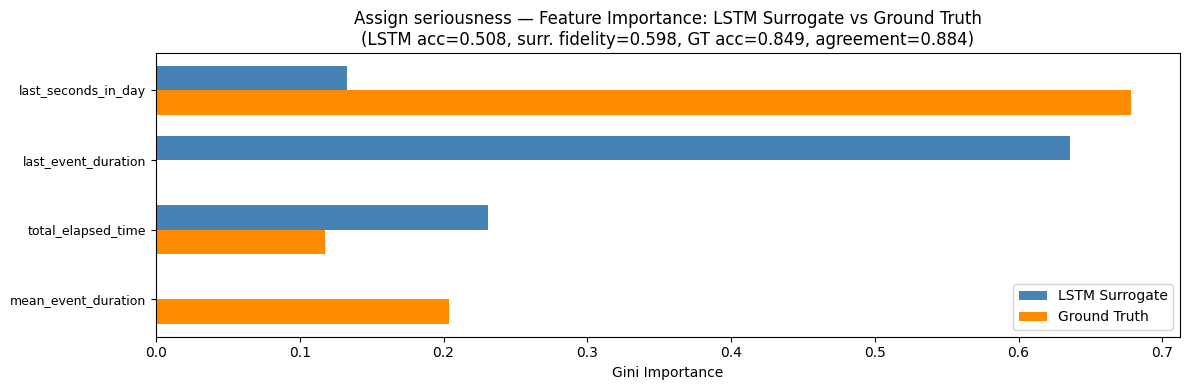

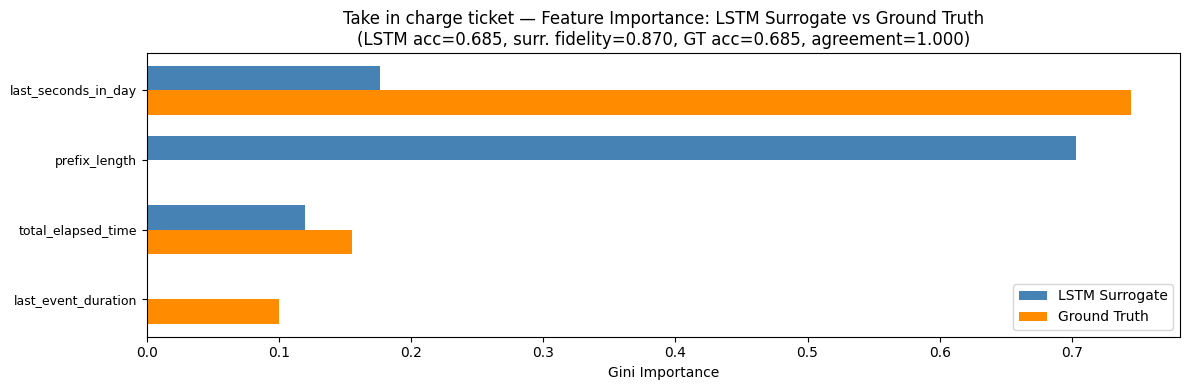

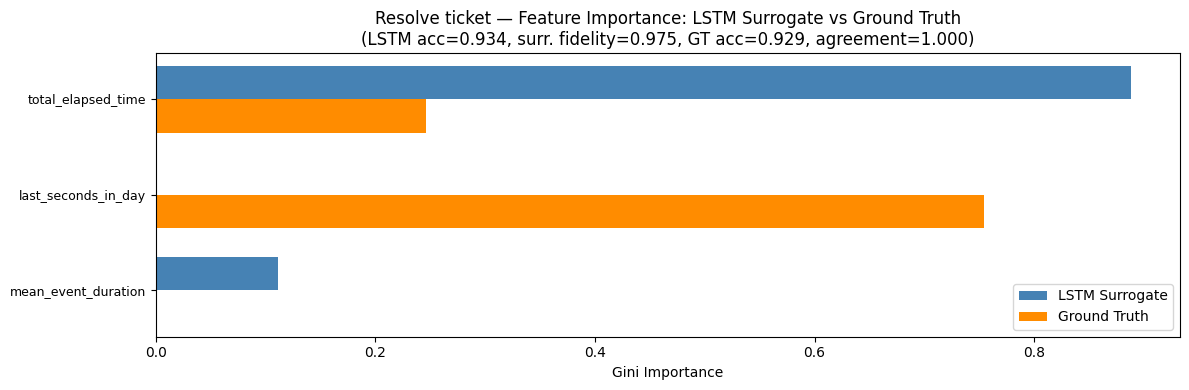

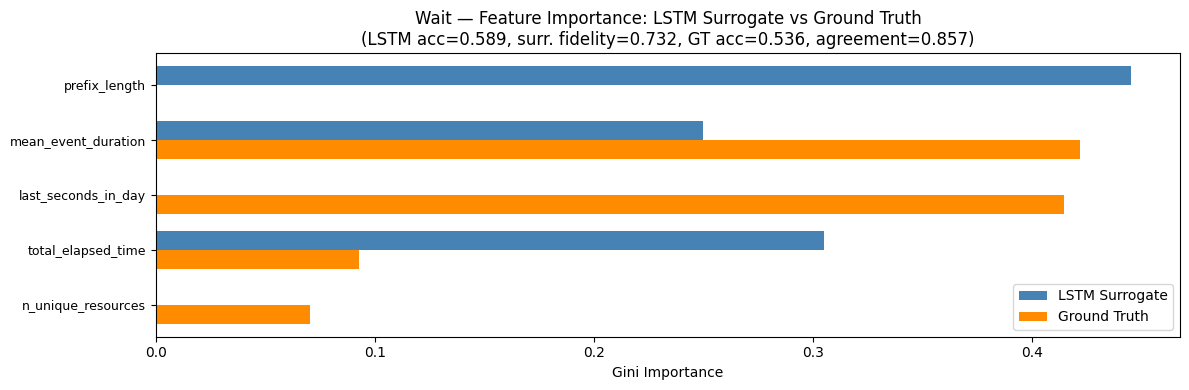

In [7]:
for gateway_act, gr in gateway_results.items():
    fn = gr['feature_names']
    imp_lstm = gr['clf_lstm'].feature_importances_
    imp_gt = gr['clf_gt'].feature_importances_

    # Only show features with non-zero importance in either tree
    mask = (imp_lstm > 0) | (imp_gt > 0)
    fn_nz = [f for f, m in zip(fn, mask) if m]
    imp_lstm_nz = imp_lstm[mask]
    imp_gt_nz = imp_gt[mask]

    # Sort by max importance across both
    order = np.argsort(np.maximum(imp_lstm_nz, imp_gt_nz))[::-1]
    fn_nz = [fn_nz[i] for i in order]
    imp_lstm_nz = imp_lstm_nz[order]
    imp_gt_nz = imp_gt_nz[order]

    fig, ax = plt.subplots(figsize=(12, max(4, len(fn_nz) * 0.4)))
    y_pos = np.arange(len(fn_nz))
    bar_h = 0.35

    ax.barh(y_pos - bar_h / 2, imp_lstm_nz, bar_h, label='LSTM Surrogate', color='steelblue')
    ax.barh(y_pos + bar_h / 2, imp_gt_nz, bar_h, label='Ground Truth', color='darkorange')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(fn_nz, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Gini Importance')
    ax.set_title(f'{gateway_act} — Feature Importance: LSTM Surrogate vs Ground Truth\n'
                 f'(LSTM acc={gr["lstm_accuracy"]:.3f}, '
                 f'surr. fidelity={gr["surrogate_fidelity"]:.3f}, '
                 f'GT acc={gr["gt_accuracy"]:.3f}, '
                 f'agreement={gr["agreement"]:.3f})')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

## Side-by-side tree visualizations

Trees are capped at **depth 4** for readability. Full decision logic is in the
if/then rules section below. Split conditions show decoded category names.

In [8]:
# C4.5 trees have multi-way splits and cannot use sklearn's plot_tree.
# Instead, print the tree as readable rules.

def print_tree_rules(clf, label, max_rules=15):
    rules = clf.extract_rules()
    print(f'\n  {label} ({len(rules)} rules, showing top {min(max_rules, len(rules))}):')
    print(f'  {"─" * 70}')
    for i, rule in enumerate(rules[:max_rules]):
        conds = '\n      AND '.join(rule['conditions'])
        print(f'  Rule {i+1} (n={rule["n_samples"]}, {rule["confidence"]:.0%} confidence):')
        print(f'    IF  {conds}')
        print(f'    THEN -> {rule["prediction"]}')
        print()


for gateway_act, gr in gateway_results.items():
    print(f'{"=" * 80}')
    print(f'GATEWAY: {gateway_act}')
    print_tree_rules(gr['clf_lstm'], 'LSTM Surrogate (C4.5)')
    print_tree_rules(gr['clf_gt'], 'Ground Truth (C4.5)')

GATEWAY: Assign seriousness

  LSTM Surrogate (C4.5) (7 rules, showing top 7):
  ──────────────────────────────────────────────────────────────────────
  Rule 1 (n=439, 55% confidence):
    IF  last_event_duration > 4.094e+04
      AND total_elapsed_time <= 6.416e+04
      AND last_seconds_in_day > 2.717e+04
      AND last_seconds_in_day <= 5.786e+04
      AND last_seconds_in_day <= 5.615e+04
    THEN -> Take in charge ticket

  Rule 2 (n=33, 88% confidence):
    IF  last_event_duration > 4.094e+04
      AND total_elapsed_time > 6.416e+04
    THEN -> Take in charge ticket

  Rule 3 (n=31, 100% confidence):
    IF  last_event_duration <= 4.094e+04
      AND total_elapsed_time <= 322.1
    THEN -> Take in charge ticket

  Rule 4 (n=31, 68% confidence):
    IF  last_event_duration > 4.094e+04
      AND total_elapsed_time <= 6.416e+04
      AND last_seconds_in_day > 2.717e+04
      AND last_seconds_in_day > 5.786e+04
    THEN -> Take in charge ticket

  Rule 5 (n=23, 78% confidence):
    I

## Decision rules as readable if/then statements

Each leaf becomes one rule. Conditions along the path from root to leaf are
combined with AND. Rules are sorted by sample count (most common decisions
first).

In [9]:
# Rule extraction is now built into C45Classifier.extract_rules()
# (printed in the cell above)

## Confusion: surrogate predictions vs ground truth predictions

Where do the two trees disagree? Each cell shows how many test samples the
LSTM surrogate assigned to one branch while the ground truth tree assigned
to another.

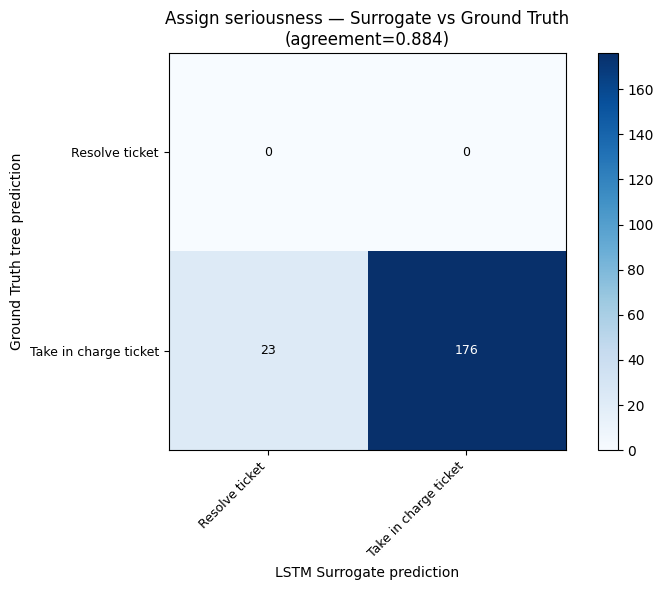

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


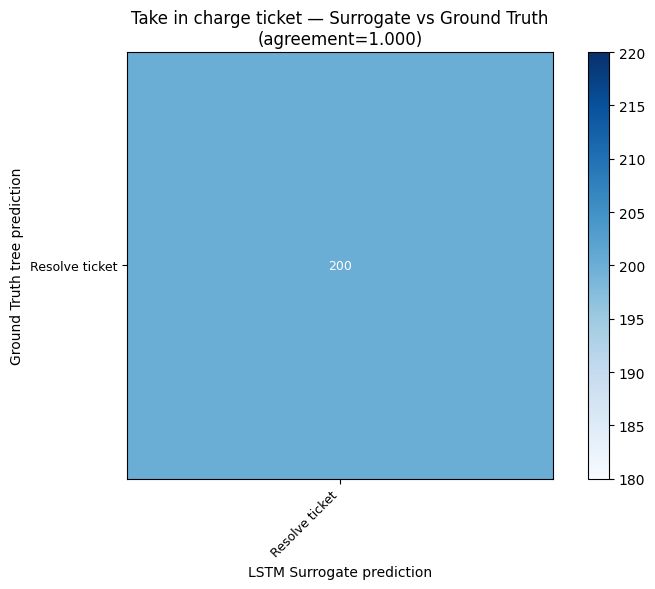

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


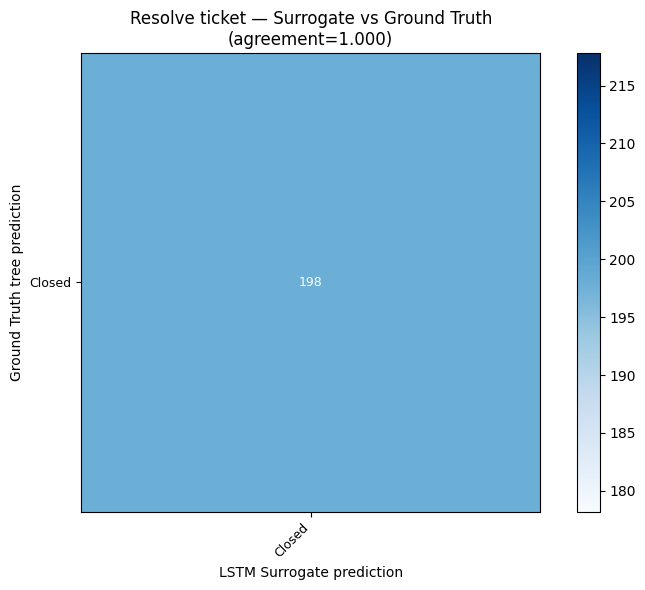

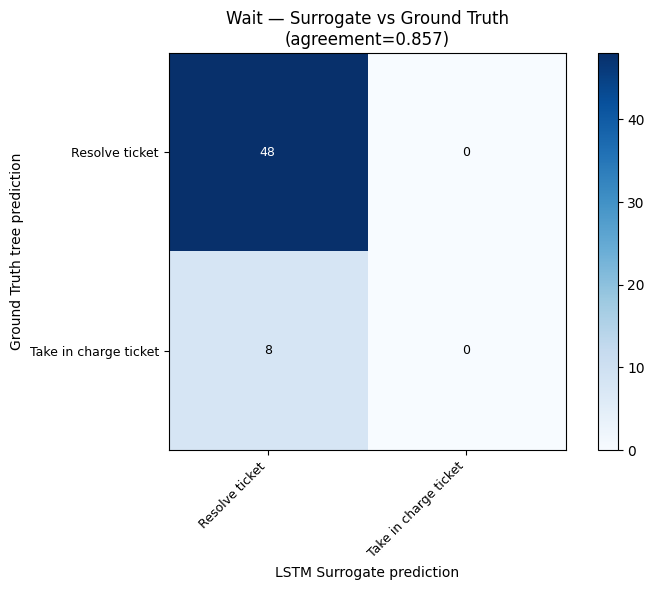

In [10]:
for gateway_act, gr in gateway_results.items():
    y_surr = gr['clf_lstm'].predict(gr['X_test'])
    y_gt = gr['clf_gt'].predict(gr['X_test'])

    labels = sorted(set(y_surr) | set(y_gt))
    cm = confusion_matrix(y_gt, y_surr, labels=labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('LSTM Surrogate prediction')
    ax.set_ylabel('Ground Truth tree prediction')
    ax.set_title(f'{gateway_act} — Surrogate vs Ground Truth\n(agreement={gr["agreement"]:.3f})')
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=9)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

## Deep dive: disagreement analysis

For the gateway with the lowest agreement rate, examine individual test cases
where the surrogate and ground truth trees predict different branches. Shows
what the LSTM actually predicted vs what happened, and which features are at
play.

In [11]:
# Find gateway with lowest agreement
worst_gateway = min(gateway_results, key=lambda g: gateway_results[g]['agreement'])
gr = gateway_results[worst_gateway]
print(f'Deepest disagreement: {worst_gateway} (agreement={gr["agreement"]:.3f})\n')

y_surr = gr['clf_lstm'].predict(gr['X_test'])
y_gt_pred = gr['clf_gt'].predict(gr['X_test'])
disagree_mask = y_surr != y_gt_pred
disagree_indices = np.where(disagree_mask)[0]

n_show = min(8, len(disagree_indices))
rng = np.random.RandomState(42)
show_indices = rng.choice(disagree_indices, size=n_show, replace=False) if len(disagree_indices) > 0 else []

for idx in show_indices:
    sample = gr['X_test'].iloc[idx]
    lstm_pred = gr['y_lstm_test'].iloc[idx] if hasattr(gr['y_lstm_test'], 'iloc') else gr['y_lstm_test'][idx]
    actual = gr['y_actual_test'].iloc[idx] if hasattr(gr['y_actual_test'], 'iloc') else gr['y_actual_test'][idx]
    surr_pred = y_surr[idx]
    gt_pred = y_gt_pred[idx]

    print(f'{"=" * 80}')
    print(f'Actual next: {actual} | LSTM predicted: {lstm_pred}')
    print(f'Surrogate tree: {surr_pred} | GT tree: {gt_pred}')

    print(f'\n  Surrogate path:')
    for i, step in enumerate(gr['clf_lstm'].explain_decision_path(sample)):
        print(f'    {i+1}. {step}')
    print(f'    -> {surr_pred}')

    print(f'\n  GT path:')
    for i, step in enumerate(gr['clf_gt'].explain_decision_path(sample)):
        print(f'    {i+1}. {step}')
    print(f'    -> {gt_pred}')
    print()

Deepest disagreement: Wait (agreement=0.857)

Actual next: Take in charge ticket | LSTM predicted: Resolve ticket
Surrogate tree: Resolve ticket | GT tree: Take in charge ticket

  Surrogate path:
    1. prefix_length = 3 <= 4.5
    2. total_elapsed_time = 541 <= 1.292e+06
    3. mean_event_duration = 3.213e+05 <= 5.764e+05
    -> Resolve ticket

  GT path:
    1. mean_event_duration = 3.213e+05 <= 8.134e+05
    2. last_seconds_in_day = 5.408e+04 > 3.069e+04
    3. total_elapsed_time = 541 <= 1.297e+06
    4. n_unique_resources = 1 <= 1.5
    -> Take in charge ticket

Actual next: Resolve ticket | LSTM predicted: Resolve ticket
Surrogate tree: Resolve ticket | GT tree: Take in charge ticket

  Surrogate path:
    1. prefix_length = 3 <= 4.5
    2. total_elapsed_time = 7.389e+04 <= 1.292e+06
    3. mean_event_duration = 3.457e+05 <= 5.764e+05
    -> Resolve ticket

  GT path:
    1. mean_event_duration = 3.457e+05 <= 8.134e+05
    2. last_seconds_in_day = 4.402e+04 > 3.069e+04
    3. to

## Depth sweep comparison

Shows how validation fidelity/accuracy evolves with tree depth for both
trees at each gateway. These curves are used only for depth selection;
test-set performance is reported once in the summary table. Helps judge
the interpretability-accuracy tradeoff.

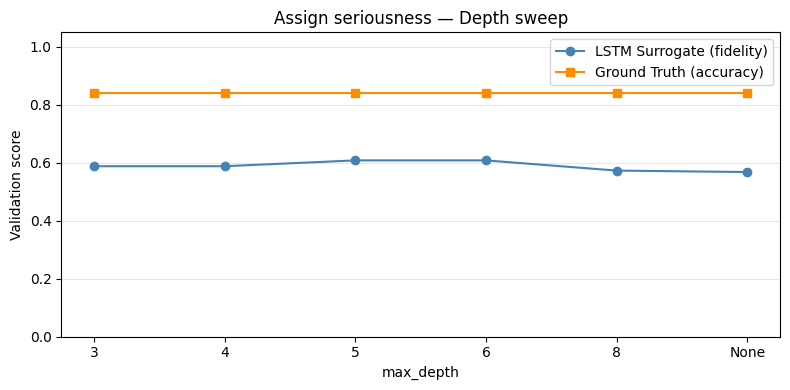

,depth,surr_train,surr_val,surr_leaves,gt_train,gt_val,gt_leaves
0,3,0.606,0.588,5,0.839,0.839,5
1,4,0.606,0.588,6,0.839,0.839,7
2,5,0.628,0.608,7,0.839,0.839,11
3,6,0.628,0.608,8,0.839,0.839,15
4,8,0.645,0.573,12,0.839,0.839,22
5,None,0.687,0.568,24,0.839,0.839,23


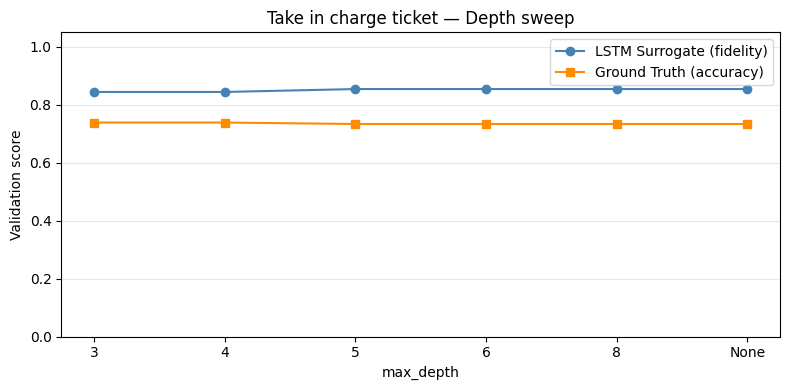

,depth,surr_train,surr_val,surr_leaves,gt_train,gt_val,gt_leaves
0,3,0.822,0.844,5,0.725,0.739,7
1,4,0.822,0.844,7,0.725,0.739,11
2,5,0.827,0.854,9,0.742,0.734,15
3,6,0.827,0.854,10,0.742,0.734,19
4,8,0.827,0.854,13,0.742,0.734,22
5,None,0.827,0.854,22,0.742,0.734,24


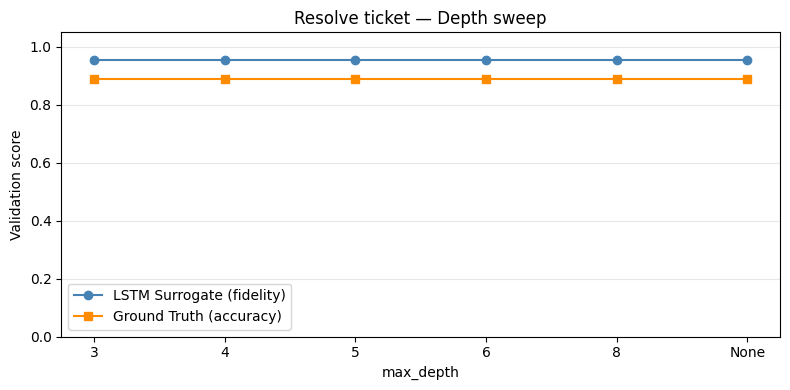

,depth,surr_train,surr_val,surr_leaves,gt_train,gt_val,gt_leaves
0,3,0.958,0.955,4,0.931,0.889,6
1,4,0.958,0.955,5,0.931,0.889,8
2,5,0.958,0.955,6,0.931,0.889,9
3,6,0.958,0.955,7,0.931,0.889,11
4,8,0.958,0.955,10,0.931,0.889,13
5,None,0.958,0.955,11,0.931,0.889,19


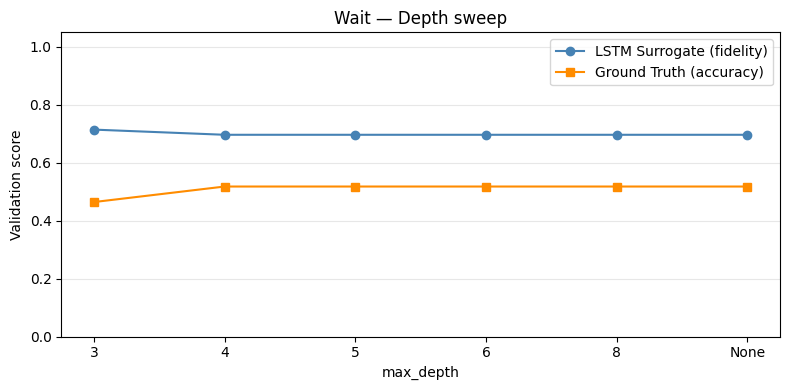

,depth,surr_train,surr_val,surr_leaves,gt_train,gt_val,gt_leaves
0,3,0.701,0.714,5,0.587,0.464,4
1,4,0.701,0.696,6,0.605,0.518,5
2,5,0.701,0.696,7,0.605,0.518,6
3,6,0.701,0.696,7,0.605,0.518,7
4,8,0.701,0.696,7,0.605,0.518,7
5,None,0.701,0.696,7,0.605,0.518,7


In [12]:
for gateway_act, gr in gateway_results.items():
    lstm_sw = gr['lstm_sweep']
    gt_sw = gr['gt_sweep']

    depths_label = [str(r['depth']) if r['depth'] is not None else 'None' for r in lstm_sw]
    lstm_val = [r['val'] for r in lstm_sw]
    gt_val = [r['val'] for r in gt_sw]

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(depths_label))
    ax.plot(x, lstm_val, 'o-', color='steelblue', label='LSTM Surrogate (fidelity)')
    ax.plot(x, gt_val, 's-', color='darkorange', label='Ground Truth (accuracy)')
    ax.set_xticks(x)
    ax.set_xticklabels(depths_label)
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Validation score')
    ax.set_title(f'{gateway_act} — Depth sweep')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Table
    rows = []
    for ls, gs in zip(lstm_sw, gt_sw):
        rows.append({
            'depth': ls['depth'] if ls['depth'] is not None else 'None',
            'surr_train': f'{ls["train"]:.3f}',
            'surr_val': f'{ls["val"]:.3f}',
            'surr_leaves': ls['clf'].get_n_leaves(),
            'gt_train': f'{gs["train"]:.3f}',
            'gt_val': f'{gs["val"]:.3f}',
            'gt_leaves': gs['clf'].get_n_leaves(),
        })
    display(pd.DataFrame(rows))